# Le GRU (Gated Recurrent Unit) en PyTorch

Ce notebook explique pas à pas le fonctionnement du **GRU**, une architecture de réseau de neurones récurrent conçue pour capturer des dépendances à long terme dans des séquences.



## Setup & Imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# Configuration globale
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 11

torch.manual_seed(42)

---

## Motivation : pourquoi le GRU ?

Un réseau récurrent classique maintient un **état caché** `a_t` qui résume l'historique de la séquence :

```
a_t = tanh(W_a · a_{t-1} + W_x · x_t + b)
```

### Problème : le gradient qui disparaît

Pour des séquences longues, le gradient se **multiplie** par les mêmes poids à chaque pas de temps.
Il tend alors vers 0 (ou explose), rendant l'apprentissage très difficile.

```
Séquence longue :
 x_1  x_2  x_3  ... x_50  x_51
  ↓    ↓    ↓         ↓    ↓
 a_1→ a_2→ a_3→ ... a_50→a_51
       gradient de a_1 ≈ 0 après 50 pas
```

### Solution : des **portes** (gates)

Le GRU introduit deux portes qui **contrôlent** le flux d'information :
- **Porte de réinitialisation** `r_t` : doit-on oublier le passé ?
- **Porte de mise à jour** `z_t` : doit-on mettre à jour l'état caché ?

Ces portes permettent au réseau d'apprendre **quand** mémoriser et **quand** oublier.

---

## Architecture du GRU : les portes

À chaque pas de temps `t`, le GRU calcule :

```
Entrées : x_t (vecteur d'entrée), a_{t-1} (état caché précédent)

┌─────────────────────────────────────────────────────────┐
│                    Cellule GRU                          │
│                                                         │
│  r_t = σ(W_r · [a_{t-1}, x_t] + b_r)   ← reset gate   │
│  z_t = σ(W_z · [a_{t-1}, x_t] + b_z)   ← update gate  │
│                                                         │
│  ñ_t = tanh(W_n · [r_t ⊙ a_{t-1}, x_t] + b_n)         │
│       ← état candidat (nouvelle mémoire potentielle)    │
│                                                         │
│  a_t = (1 - z_t) ⊙ a_{t-1} + z_t ⊙ ñ_t               │
│       ← mélange entre ancien et nouveau état            │
└─────────────────────────────────────────────────────────┘

σ = sigmoïde (sortie entre 0 et 1)
⊙ = produit élément par élément (Hadamard)
```

### Intuition des portes

| Porte | Valeur ≈ 0 | Valeur ≈ 1 |
|-------|-----------|------------|
| `r_t` (reset) | Ignore le passé pour calculer ñ_t | Utilise tout le passé |
| `z_t` (update) | Garde l'état passé a_{t-1} tel quel | Remplace par le candidat ñ_t |

### Visualisation du rôle des portes

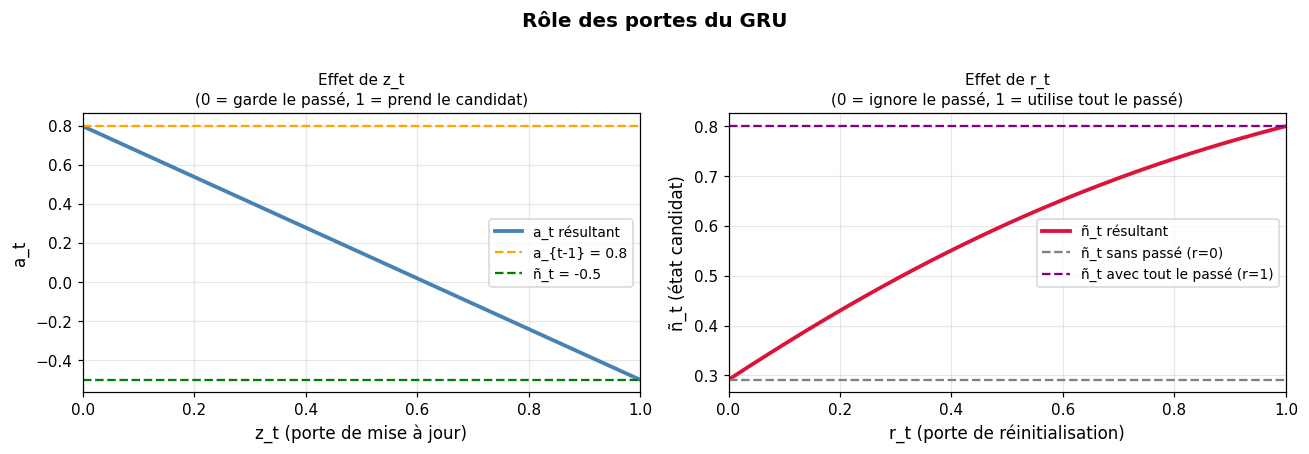

In [2]:
def visualiser_portes():
    """Visualise l'effet des portes r et z sur l'état caché."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # --- Porte de mise à jour z ---
    z_vals = np.linspace(0, 1, 50)
    a_prev = np.ones(50) * 0.8   # état précédent
    h_cand = np.ones(50) * -0.5  # état candidat
    a_new = (1 - z_vals) * a_prev + z_vals * h_cand

    ax = axes[0]
    ax.plot(z_vals, a_new, color='steelblue', linewidth=2.5, label='a_t résultant')
    ax.axhline(a_prev[0], color='orange', linestyle='--', label=f'a_{{t-1}} = {a_prev[0]}')
    ax.axhline(h_cand[0], color='green', linestyle='--', label=f'ñ_t = {h_cand[0]}')
    ax.set_xlabel('z_t (porte de mise à jour)', fontsize=11)
    ax.set_ylabel('a_t', fontsize=11)
    ax.set_title('Effet de z_t\n(0 = garde le passé, 1 = prend le candidat)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)

    # --- Porte de réinitialisation r ---
    r_vals = np.linspace(0, 1, 50)
    a_prev_r = np.ones(50) * 0.8
    # ñ_t = tanh(r * a_prev + x)  avec x = 0.3 fixé pour l'illustration
    x_fixe = 0.3
    h_cand_r = np.tanh(r_vals * a_prev_r + x_fixe)

    ax2 = axes[1]
    ax2.plot(r_vals, h_cand_r, color='crimson', linewidth=2.5, label='ñ_t résultant')
    ax2.axhline(np.tanh(x_fixe), color='gray', linestyle='--', label='ñ_t sans passé (r=0)')
    ax2.axhline(np.tanh(a_prev_r[0] + x_fixe), color='purple', linestyle='--', label='ñ_t avec tout le passé (r=1)')
    ax2.set_xlabel('r_t (porte de réinitialisation)', fontsize=11)
    ax2.set_ylabel('ñ_t (état candidat)', fontsize=11)
    ax2.set_title('Effet de r_t\n(0 = ignore le passé, 1 = utilise tout le passé)', fontsize=10)
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)
    ax2.set_xlim(0, 1)

    plt.suptitle('Rôle des portes du GRU', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

visualiser_portes()

---

## Implémentation manuelle du GRU

On va implémenter **à la main** une cellule GRU pour bien comprendre les calculs internes, avant d'utiliser la version PyTorch.

In [3]:
def sigmoid(x: torch.Tensor) -> torch.Tensor:
    """Fonction sigmoïde élément par élément."""
    return 1 / (1 + torch.exp(-x))


class GRUCellManuelle:
    """
    Cellule GRU implémentée manuellement avec des matrices de poids explicites.

    Paramètres :
        taille_entree  : dimension du vecteur d'entrée x_t
        taille_cachee  : dimension de l'état caché a_t
    """

    def __init__(self, taille_entree: int, taille_cachee: int):
        self.taille_cachee = taille_cachee

        # --- Poids pour la porte de réinitialisation r ---
        self.W_r = torch.randn(taille_cachee, taille_entree) * 0.1
        self.U_r = torch.randn(taille_cachee, taille_cachee) * 0.1
        self.b_r = torch.zeros(taille_cachee)

        # --- Poids pour la porte de mise à jour z ---
        self.W_z = torch.randn(taille_cachee, taille_entree) * 0.1
        self.U_z = torch.randn(taille_cachee, taille_cachee) * 0.1
        self.b_z = torch.zeros(taille_cachee)

        # --- Poids pour l'état candidat ñ ---
        self.W_n = torch.randn(taille_cachee, taille_entree) * 0.1
        self.U_n = torch.randn(taille_cachee, taille_cachee) * 0.1
        self.b_n = torch.zeros(taille_cachee)

    def forward(self, x_t: torch.Tensor, a_prev: torch.Tensor) -> dict:
        """
        Calcule un pas de temps du GRU.

        Args:
            x_t    : vecteur d'entrée au temps t   — shape (taille_entree,)
            a_prev : état caché au temps t-1        — shape (taille_cachee,)

        Returns:
            dict avec a_t (nouvel état) et les valeurs intermédiaires
        """
        # Porte de réinitialisation
        r_t = sigmoid(self.W_r @ x_t + self.U_r @ a_prev + self.b_r)

        # Porte de mise à jour
        z_t = sigmoid(self.W_z @ x_t + self.U_z @ a_prev + self.b_z)

        # État candidat (ñ_t) — r_t filtre la contribution du passé
        n_t = torch.tanh(self.W_n @ x_t + self.U_n @ (r_t * a_prev) + self.b_n)

        # Nouvel état caché — mélange entre passé et candidat
        a_t = (1 - z_t) * a_prev + z_t * n_t

        return {"a_t": a_t, "r_t": r_t, "z_t": z_t, "n_t": n_t}


# --- Exemple avec des dimensions jouets ---
taille_entree  = 4   # ex. vecteur d'entrée de dimension 4
taille_cachee  = 3   # ex. état caché de dimension 3

cellule = GRUCellManuelle(taille_entree, taille_cachee)

x_t    = torch.tensor([1.0, 0.5, -0.3, 0.8])  # entrée au temps t
a_prev = torch.zeros(taille_cachee)              # état initial = 0

resultats = cellule.forward(x_t, a_prev)

print("=== Pas de temps t=1 ===")
print(f"  r_t (reset gate)  : {resultats['r_t'].detach().numpy().round(3)}")
print(f"  z_t (update gate) : {resultats['z_t'].detach().numpy().round(3)}")
print(f"  ñ_t (candidat)    : {resultats['n_t'].detach().numpy().round(3)}")
print(f"  a_t (nouvel état) : {resultats['a_t'].detach().numpy().round(3)}")

=== Pas de temps t=1 ===
  r_t (reset gate)  : [0.513 0.441 0.527]
  z_t (update gate) : [0.513 0.509 0.51 ]
  ñ_t (candidat)    : [-0.131 -0.088 -0.057]
  a_t (nouvel état) : [-0.067 -0.045 -0.029]


### Visualisation des valeurs internes sur une séquence

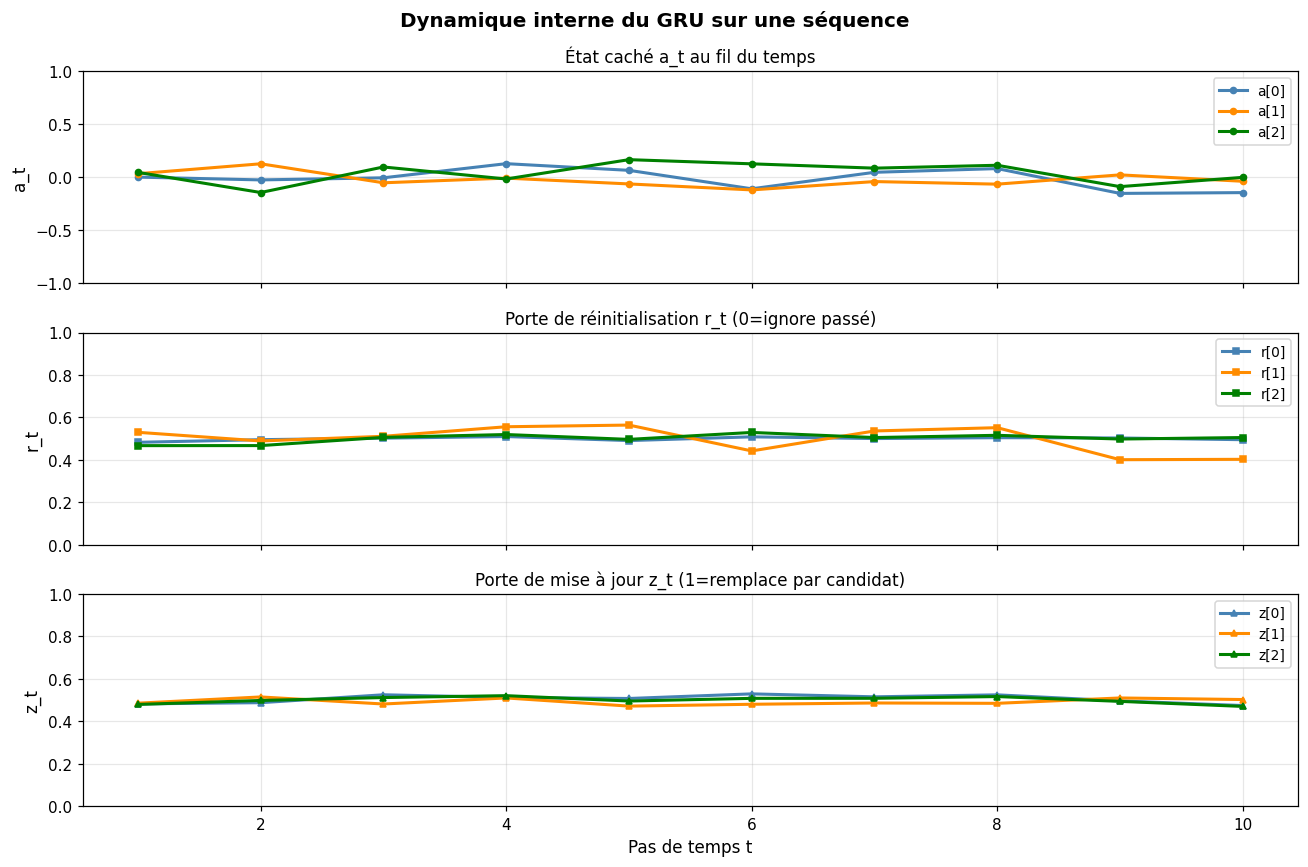

In [4]:
def visualiser_sequence_gru(cellule: GRUCellManuelle, sequence: torch.Tensor):
    """
    Passe une séquence dans la cellule GRU manuelle et visualise
    les états cachés et les valeurs des portes à chaque pas.

    Args:
        cellule  : instance de GRUCellManuelle
        sequence : tensor de shape (longueur_seq, taille_entree)
    """
    longueur_seq = sequence.shape[0]

    # Accumulateurs
    a_history = []
    r_history = []
    z_history = []

    a = torch.zeros(cellule.taille_cachee)
    for t in range(longueur_seq):
        res = cellule.forward(sequence[t], a)
        a = res["a_t"]
        a_history.append(a.detach().numpy().copy())
        r_history.append(res["r_t"].detach().numpy().copy())
        z_history.append(res["z_t"].detach().numpy().copy())

    a_arr = np.array(a_history)  # (longueur_seq, taille_cachee)
    r_arr = np.array(r_history)
    z_arr = np.array(z_history)
    temps = np.arange(1, longueur_seq + 1)

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    couleurs = ['steelblue', 'darkorange', 'green']

    for i in range(cellule.taille_cachee):
        axes[0].plot(temps, a_arr[:, i], color=couleurs[i], linewidth=2,
                     label=f'a[{i}]', marker='o', markersize=4)
        axes[1].plot(temps, r_arr[:, i], color=couleurs[i], linewidth=2,
                     label=f'r[{i}]', marker='s', markersize=4)
        axes[2].plot(temps, z_arr[:, i], color=couleurs[i], linewidth=2,
                     label=f'z[{i}]', marker='^', markersize=4)

    axes[0].set_ylabel('a_t', fontsize=11)
    axes[0].set_title('État caché a_t au fil du temps', fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim(-1, 1)

    axes[1].set_ylabel('r_t', fontsize=11)
    axes[1].set_title('Porte de réinitialisation r_t (0=ignore passé)', fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim(0, 1)

    axes[2].set_ylabel('z_t', fontsize=11)
    axes[2].set_title('Porte de mise à jour z_t (1=remplace par candidat)', fontsize=11)
    axes[2].legend(fontsize=9)
    axes[2].grid(alpha=0.3)
    axes[2].set_ylim(0, 1)
    axes[2].set_xlabel('Pas de temps t', fontsize=11)

    plt.suptitle('Dynamique interne du GRU sur une séquence', fontsize=13,
                 fontweight='bold')
    plt.tight_layout()
    plt.show()


# Séquence de test : 10 pas de temps, entrées aléatoires
torch.manual_seed(0)
seq_test = torch.randn(10, taille_entree)
visualiser_sequence_gru(cellule, seq_test)

---

## Utilisation de `torch.nn.GRU`

PyTorch fournit une implémentation optimisée du GRU via `torch.nn.GRU`.

### Paramètres principaux

```python
nn.GRU(
    input_size,    # dimension de x_t
    hidden_size,   # dimension de a_t
    num_layers=1,  # nombre de couches GRU empilées
    batch_first=True,  # si True : entrée de shape (batch, seq, features)
    dropout=0.0,   # dropout entre les couches (si num_layers > 1)
    bidirectional=False  # GRU bidirectionnel
)
```

### Forme des tenseurs

```
Entrée  : (batch_size, longueur_seq, taille_entree)   ← si batch_first=True
Sortie  : (batch_size, longueur_seq, taille_cachee)   ← sorties à chaque pas
a_n     : (num_layers, batch_size, taille_cachee)     ← état final
```

In [5]:
# --- Configuration ---
taille_entree  = 4
taille_cachee  = 8
longueur_seq   = 10
batch_size     = 2

# --- Création du GRU PyTorch ---
gru = nn.GRU(
    input_size=taille_entree,
    hidden_size=taille_cachee,
    num_layers=1,
    batch_first=True
)

print("Architecture du GRU :")
print(gru)
print()

# Nombre de paramètres
nb_params = sum(p.numel() for p in gru.parameters())
print(f"Nombre total de paramètres : {nb_params}")
print(f"  (3 portes × 2 matrices × taille_cachee × (taille_entree + taille_cachee) + biais)")

# --- Passage d'un batch ---
x = torch.randn(batch_size, longueur_seq, taille_entree)
a0 = torch.zeros(1, batch_size, taille_cachee)  # état initial

sorties, a_final = gru(x, a0)

print(f"\nForme de l'entrée        : {x.shape}")
print(f"Forme des sorties        : {sorties.shape}")
print(f"Forme de l'état final    : {a_final.shape}")

Architecture du GRU :
GRU(4, 8, batch_first=True)

Nombre total de paramètres : 336
  (3 portes × 2 matrices × taille_cachee × (taille_entree + taille_cachee) + biais)

Forme de l'entrée        : torch.Size([2, 10, 4])
Forme des sorties        : torch.Size([2, 10, 8])
Forme de l'état final    : torch.Size([1, 2, 8])


### GRU multicouche

In [6]:
# GRU avec 2 couches empilées
gru_2couches = nn.GRU(
    input_size=taille_entree,
    hidden_size=taille_cachee,
    num_layers=2,
    batch_first=True,
    dropout=0.1  # dropout entre les couches
)

a0_2 = torch.zeros(2, batch_size, taille_cachee)  # num_layers=2
sorties_2, a_final_2 = gru_2couches(x, a0_2)

print("GRU 2 couches :")
print(f"  Sorties   : {sorties_2.shape}")
print(f"  a_final   : {a_final_2.shape}  ← (num_layers, batch, hidden)")
print(f"  a couche 1 : {a_final_2[0].shape}")
print(f"  a couche 2 : {a_final_2[1].shape}")

GRU 2 couches :
  Sorties   : torch.Size([2, 10, 8])
  a_final   : torch.Size([2, 2, 8])  ← (num_layers, batch, hidden)
  a couche 1 : torch.Size([2, 8])
  a couche 2 : torch.Size([2, 8])


### Visualisation : sorties vs état caché

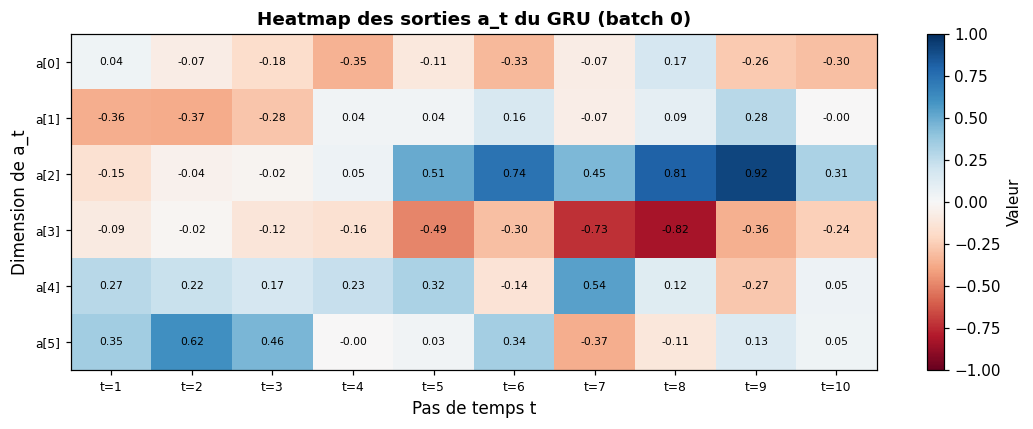

In [7]:
def visualiser_sorties_gru(sorties: torch.Tensor, titre: str = "Sorties du GRU"):
    """
    Affiche sous forme de heatmap les sorties du GRU pour chaque pas de temps.

    Args:
        sorties : tensor de shape (batch_size, longueur_seq, taille_cachee)
        titre   : titre du graphique
    """
    # Prend le premier élément du batch
    data = sorties[0].detach().numpy()  # (longueur_seq, taille_cachee)

    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(data.T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1,
                   interpolation='nearest')

    # Annotations des valeurs
    for i in range(data.shape[1]):
        for j in range(data.shape[0]):
            ax.text(j, i, f'{data[j, i]:.2f}', ha='center', va='center',
                    fontsize=7, color='black')

    ax.set_xlabel('Pas de temps t', fontsize=11)
    ax.set_ylabel('Dimension de a_t', fontsize=11)
    ax.set_title(titre, fontsize=12, fontweight='bold')
    ax.set_xticks(range(data.shape[0]))
    ax.set_xticklabels([f't={i+1}' for i in range(data.shape[0])], fontsize=8)
    ax.set_yticks(range(data.shape[1]))
    ax.set_yticklabels([f'a[{i}]' for i in range(data.shape[1])], fontsize=8)

    plt.colorbar(im, ax=ax, label='Valeur')
    plt.tight_layout()
    plt.show()


torch.manual_seed(1)
x_demo = torch.randn(1, 10, taille_entree)
gru_demo = nn.GRU(input_size=taille_entree, hidden_size=6, batch_first=True)
sorties_demo, _ = gru_demo(x_demo)

visualiser_sorties_gru(sorties_demo, "Heatmap des sorties a_t du GRU (batch 0)")

---

## Application : prédiction de séquence sinusoïdale

On va entraîner un GRU à **prédire le prochain point** d'une sinusoïde.
C'est un problème de prédiction de série temporelle.

```
Entrée  : [x_1, x_2, ..., x_T]     (séquence passée)
Sortie  : x_{T+1}                   (prochain point)
```

Signal généré : 600 points
Séquences     : X_train=torch.Size([464, 20, 1]), y_train=torch.Size([464, 1])
               X_test=torch.Size([116, 20, 1]),  y_test=torch.Size([116, 1])


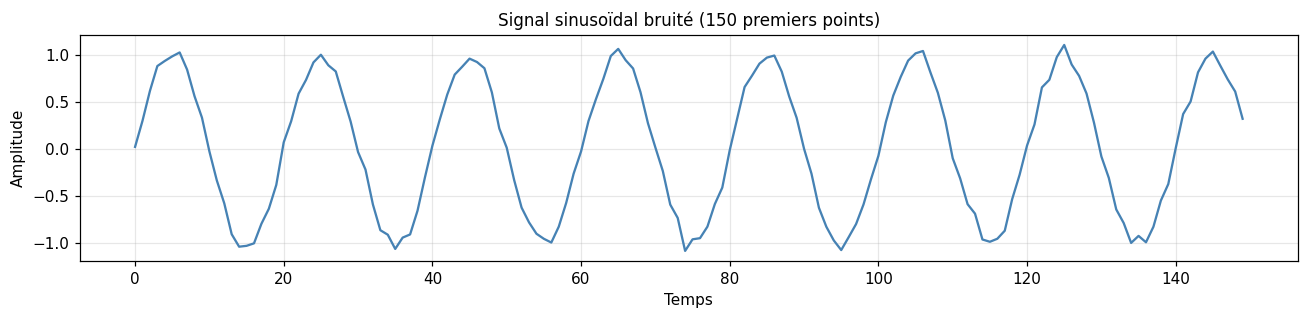

In [8]:
# --- Génération des données ---
def generer_sinusoide(nb_points: int = 500, frequence: float = 0.05,
                      bruit: float = 0.05) -> np.ndarray:
    """Génère une sinusoïde bruitée."""
    t = np.arange(nb_points)
    signal = np.sin(2 * np.pi * frequence * t) + bruit * np.random.randn(nb_points)
    return signal.astype(np.float32)


def creer_sequences(signal: np.ndarray, longueur_seq: int):
    """
    Crée des paires (séquence_entree, valeur_cible) pour la prédiction.

    Returns:
        X : (nb_exemples, longueur_seq, 1)
        y : (nb_exemples, 1)
    """
    X, y = [], []
    for i in range(len(signal) - longueur_seq):
        X.append(signal[i:i + longueur_seq])
        y.append(signal[i + longueur_seq])
    X = np.array(X)[:, :, np.newaxis]  # ajoute dim feature
    y = np.array(y)[:, np.newaxis]
    return torch.FloatTensor(X), torch.FloatTensor(y)


np.random.seed(42)
signal = generer_sinusoide(nb_points=600)
longueur_seq = 20

X, y = creer_sequences(signal, longueur_seq)

# Split train / test
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Signal généré : {len(signal)} points")
print(f"Séquences     : X_train={X_train.shape}, y_train={y_train.shape}")
print(f"               X_test={X_test.shape},  y_test={y_test.shape}")

# Visualisation du signal
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(signal[:150], color='steelblue', linewidth=1.5)
ax.set_title('Signal sinusoïdal bruité (150 premiers points)', fontsize=11)
ax.set_xlabel('Temps', fontsize=10)
ax.set_ylabel('Amplitude', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
class ModeleGRU(nn.Module):
    """
    Modèle GRU pour la prédiction de série temporelle.

    Architecture :
        GRU → couche linéaire de sortie
    """

    def __init__(self, taille_entree: int = 1, taille_cachee: int = 32,
                 nb_couches: int = 1, taille_sortie: int = 1):
        super().__init__()
        self.taille_cachee = taille_cachee
        self.nb_couches = nb_couches

        self.gru = nn.GRU(
            input_size=taille_entree,
            hidden_size=taille_cachee,
            num_layers=nb_couches,
            batch_first=True
        )
        self.fc = nn.Linear(taille_cachee, taille_sortie)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (batch, longueur_seq, taille_entree)
        Returns:
            y : (batch, taille_sortie)
        """
        # a0 initialisé à zéro automatiquement si non fourni
        sorties, a_final = self.gru(x)
        # On utilise uniquement le dernier état caché
        derniere_sortie = sorties[:, -1, :]  # (batch, taille_cachee)
        prediction = self.fc(derniere_sortie)
        return prediction


modele = ModeleGRU(taille_entree=1, taille_cachee=32, nb_couches=1)
print(modele)
print(f"\nParamètres totaux : {sum(p.numel() for p in modele.parameters())}")

ModeleGRU(
  (gru): GRU(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Paramètres totaux : 3393


In [10]:
# --- Entraînement ---
critere    = nn.MSELoss()
optimiseur = torch.optim.Adam(modele.parameters(), lr=1e-3)

nb_epochs    = 100
taille_batch = 32
historique_pertes = []

for epoch in range(nb_epochs):
    modele.train()
    perte_epoch = 0.0
    nb_batches  = 0

    # Mélange des données
    indices = torch.randperm(len(X_train))
    X_mel   = X_train[indices]
    y_mel   = y_train[indices]

    for i in range(0, len(X_train), taille_batch):
        X_batch = X_mel[i:i + taille_batch]
        y_batch = y_mel[i:i + taille_batch]

        optimiseur.zero_grad()
        prediction = modele(X_batch)
        perte = critere(prediction, y_batch)
        perte.backward()
        optimiseur.step()

        perte_epoch += perte.item()
        nb_batches  += 1

    perte_moy = perte_epoch / nb_batches
    historique_pertes.append(perte_moy)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{nb_epochs} — Perte MSE : {perte_moy:.6f}")

print("\nEntraînement terminé.")

Epoch  20/100 — Perte MSE : 0.003419
Epoch  40/100 — Perte MSE : 0.003192
Epoch  60/100 — Perte MSE : 0.003105
Epoch  80/100 — Perte MSE : 0.002879
Epoch 100/100 — Perte MSE : 0.002899

Entraînement terminé.


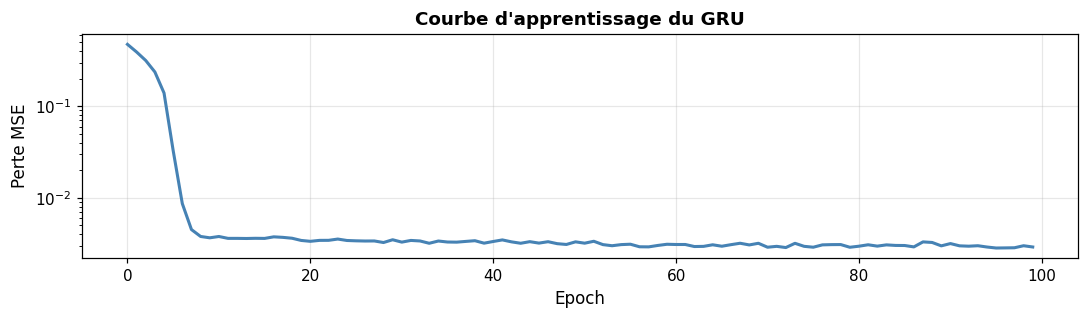

In [11]:
# --- Courbe d'apprentissage ---
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(historique_pertes, color='steelblue', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Perte MSE', fontsize=11)
ax.set_title('Courbe d\'apprentissage du GRU', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

MSE sur le jeu de test : 0.002932


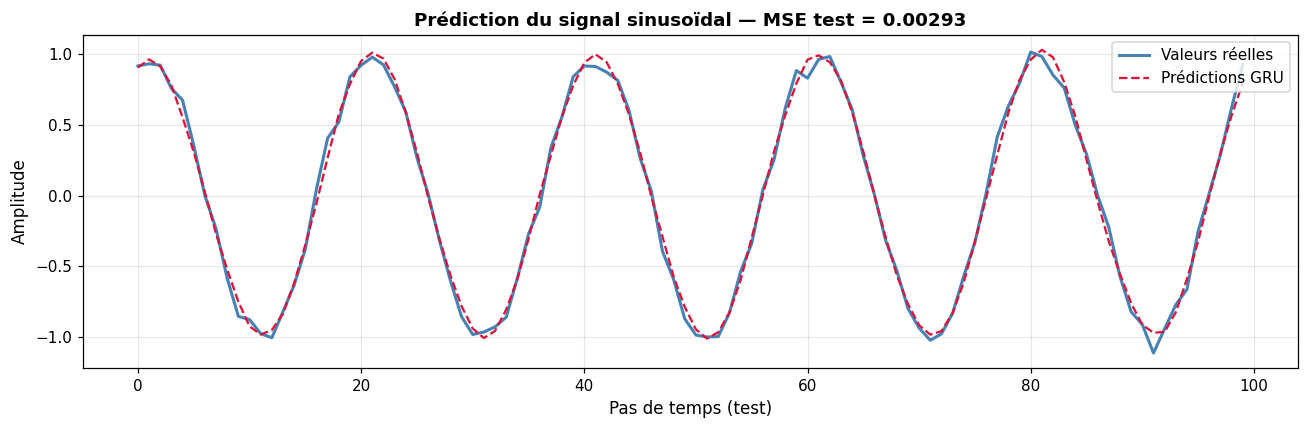

In [12]:
# --- Évaluation sur le test ---
modele.eval()
with torch.no_grad():
    predictions_test = modele(X_test).numpy().flatten()
    y_test_np        = y_test.numpy().flatten()

mse_test = np.mean((predictions_test - y_test_np) ** 2)
print(f"MSE sur le jeu de test : {mse_test:.6f}")

# Visualisation
fig, ax = plt.subplots(figsize=(12, 4))
n_affiche = min(100, len(y_test_np))
ax.plot(y_test_np[:n_affiche],       color='steelblue', linewidth=2,   label='Valeurs réelles')
ax.plot(predictions_test[:n_affiche], color='crimson',  linewidth=1.5,
        linestyle='--', label='Prédictions GRU')
ax.set_xlabel('Pas de temps (test)', fontsize=11)
ax.set_ylabel('Amplitude', fontsize=11)
ax.set_title(f'Prédiction du signal sinusoïdal — MSE test = {mse_test:.5f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()